<a href="https://colab.research.google.com/github/kelvinjfloresy/wildfire-burn-severity-sentinel2-gee/blob/main/notebooks/Wildfire_Risk_Pipeline_Niebla2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

>> Tarea iniciada: Exportación GeoTIFF Multibanda hacia Drive /Niebla_Wildfire_2026

================== BALANCE CARTOGRÁFICO OFICIAL ==================
 Clase                         Descripción  Superficie (ha)  Porcentaje (%)
     1        No Afectado / Rebrote (<100)          5854.61           13.35
     2          Severidad Baja (100 - 269)          9587.66           21.86
     3 Severidad Moderada-Baja (270 - 439)         13072.49           29.80
     4 Severidad Moderada-Alta (440 - 659)         11891.72           27.11
     5              Severidad Alta (>=660)          3454.29            7.88
Total superficie analizada: 43860.77 ha


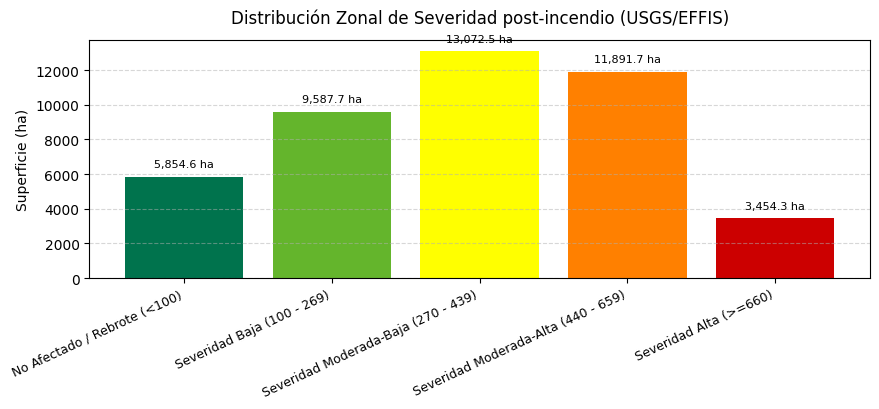

In [6]:
"""
================================================================================
PIPELINE DE TELEDETECCIÓN SATELITAL & MODELADO DE RIESGO POST-INCENDIO (MSI S2)
Caso de Estudio: Gran Incendio Forestal (GIF) de Niebla, Huelva
Marco Regulatorio: RDL 15/2022 | Directrices USGS/EFFIS | Inventario Forestal IFN4
Autor: Kelvin Jesus Flores Yarihuaman (Ingeniero Ambiental)
================================================================================
"""

import ee
import pandas as pd
import matplotlib.pyplot as plt
import folium

# 1. Inicialización vinculada a Google Cloud Project
PROJECT_ID = 'ee-niebla-analisis'

try:
    ee.Initialize(project=PROJECT_ID)
except Exception:
    ee.Authenticate()
    ee.Initialize(project=PROJECT_ID)

class WildfireRiskPipeline:
    def __init__(self, coordinates, epsg='EPSG:25829'):
        self.roi = ee.Geometry.Polygon([coordinates])
        self.epsg = epsg
        self.s2_collection = 'COPERNICUS/S2_SR_HARMONIZED'
        self.dem_collection = 'COPERNICUS/DEM/GLO30'

    def mask_clouds_scl(self, image):
        """
        Máscara por exclusión: filtra sombras (3), nubes medias/altas (8, 9), cirros (10) y nieve (11).
        Conserva áreas oscuras/cenizas de alta severidad (2) y suelo/vegetación (4-7).
        """
        scl = image.select('SCL')
        cloud_shadow_mask = scl.eq(3).Or(scl.gte(8).And(scl.lte(11)))
        return image.updateMask(cloud_shadow_mask.Not())

    def get_composite(self, date_start, date_end):
        """Genera mosaico Sentinel-2 y calcula NBR"""
        composite = (ee.ImageCollection(self.s2_collection)
            .filterBounds(self.roi)
            .filterDate(date_start, date_end)
            .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 20))
            .map(self.mask_clouds_scl)
            .median()
            .clip(self.roi))

        # NBR = (B8 - B12) / (B8 + B12)
        nbr = composite.normalizedDifference(['B8', 'B12']).rename('NBR')
        return composite.addBands(nbr)

    def get_topography(self):
        """Modelo digital de elevación y cálculo de pendiente re-proyectado a UTM métrico"""
        dem = (ee.ImageCollection(self.dem_collection)
               .filterBounds(self.roi)
               .select('DEM')
               .mosaic()
               .reproject(crs=self.epsg, scale=30)
               .clip(self.roi))

        # Pendiente directa en grados sexagesimales (°)
        slope_deg = ee.Terrain.slope(dem).rename('Slope_Degrees')
        return dem.rename('Elevation'), slope_deg

    def process_burn_severity(self, pre_dates, post_dates):
        """Computa dNBR, RBR, Severidad USGS, Factor C RUSLE y Prioridad de Erosión"""
        pre_img = self.get_composite(pre_dates[0], pre_dates[1])
        post_img = self.get_composite(post_dates[0], post_dates[1])

        pre_nbr = pre_img.select('NBR')
        post_nbr = post_img.select('NBR')

        # dNBR escalado x1000 según estándar internacional
        dnbr = pre_nbr.subtract(post_nbr).multiply(1000).rename('dNBR')

        # Relativized Burn Ratio (RBR)
        rbr = dnbr.divide(pre_nbr.add(1.001)).rename('RBR')

        # Clasificación discreta USGS / EFFIS (1 a 5)
        severity = ee.Image(1) \
            .where(dnbr.gte(100).And(dnbr.lt(270)), 2) \
            .where(dnbr.gte(270).And(dnbr.lt(440)), 3) \
            .where(dnbr.gte(440).And(dnbr.lt(660)), 4) \
            .where(dnbr.gte(660), 5) \
            .clip(self.roi) \
            .rename('Severity_Class')

        # Asignación de Factor C RUSLE mediante remap
        factor_c = severity.remap(
            [1, 2, 3, 4, 5],
            [0.02, 0.08, 0.20, 0.45, 0.65]
        ).rename('Factor_C_RUSLE')

        # Modelo Topográfico
        elev, slope = self.get_topography()

        # Matriz de Prioridad de Erosión en Laderas (calibrada para Huelva)
        # 1: Muy baja/Llano | 2: Media (>=5°) | 3: Alta (>=8°) | 4: Crítica (>=12°)
        erosion_priority = ee.Image(1) \
            .where(severity.gte(3).And(slope.gte(5)), 2) \
            .where(severity.gte(4).And(slope.gte(8)), 3) \
            .where(severity.eq(5).And(slope.gte(12)), 4) \
            .clip(self.roi) \
            .rename('Erosion_Priority')

        raster_stack = dnbr.addBands([rbr, severity, factor_c, slope, erosion_priority])

        return {
            'raster': raster_stack,
            'pre_rgb': pre_img.select(['B12', 'B8', 'B4']),
            'post_rgb': post_img.select(['B12', 'B8', 'B4']),
            'severity': severity,
            'erosion_priority': erosion_priority
        }

    def calculate_metrics(self, processed_raster):
        """Balance zonal métrico de hectáreas por nivel de severidad"""
        area_band = ee.Image.pixelArea().divide(10000).rename('Area_ha')
        combined = area_band.addBands(processed_raster.select('Severity_Class'))

        stats = combined.reduceRegion(
            reducer=ee.Reducer.sum().group(groupField=1, groupName='clase'),
            geometry=self.roi,
            scale=20,
            maxPixels=1e9
        )
        return stats.getInfo()

    def export_geotiff(self, processed_raster, folder_name='Niebla_Wildfire_2026'):
        """Exporta ráster multibanda (Float32 unificado) a Google Drive"""
        bands_to_export = processed_raster.select([
            'dNBR', 'RBR', 'Severity_Class', 'Factor_C_RUSLE', 'Slope_Degrees', 'Erosion_Priority'
        ]).toFloat()

        task = ee.batch.Export.image.toDrive(
            image=bands_to_export,
            description='GeoTIFF_Multicriterio_Niebla_2026',
            folder=folder_name,
            scale=20,
            region=self.roi,
            fileFormat='GeoTIFF',
            crs=self.epsg,
            maxPixels=1e9
        )
        task.start()
        print(f">> Tarea iniciada: Exportación GeoTIFF Multibanda hacia Drive /{folder_name}")

# --- PARÁMETROS GEOGRÁFICOS ---

coords_niebla = [
    [-6.3062, 37.537], [-6.3185, 37.5308], [-6.3289, 37.5235], [-6.3587, 37.5236],
    [-6.3972, 37.5102], [-6.4348, 37.5108], [-6.4542, 37.5072], [-6.4981, 37.5065],
    [-6.4946, 37.4897], [-6.4847, 37.49], [-6.4723, 37.4825], [-6.488, 37.478],
    [-6.5088, 37.4665], [-6.5409, 37.4521], [-6.5671, 37.4459], [-6.6013, 37.4356],
    [-6.6305, 37.4533], [-6.6726, 37.4512], [-6.6964, 37.4601], [-6.7186, 37.4794],
    [-6.7031, 37.4933], [-6.6663, 37.5265], [-6.6522, 37.5676], [-6.6316, 37.6099],
    [-6.6062, 37.6177], [-6.572, 37.611], [-6.5542, 37.612], [-6.5421, 37.6227],
    [-6.5144, 37.6117], [-6.5228, 37.5887], [-6.4966, 37.5889], [-6.4843, 37.5957],
    [-6.4557, 37.6083], [-6.438, 37.6118], [-6.4291, 37.6071], [-6.4289, 37.613],
    [-6.4028, 37.6095], [-6.3749, 37.6016], [-6.3722, 37.5803], [-6.3714, 37.5609],
    [-6.3505, 37.5731], [-6.3287, 37.59], [-6.2908, 37.5904], [-6.2741, 37.5704],
    [-6.293, 37.5522], [-6.2972, 37.5639], [-6.2906, 37.5535], [-6.2964, 37.5439],
    [-6.2897, 37.5363], [-6.3084, 37.5378], [-6.3062, 37.537]
]

# --- EJECUCIÓN DEL PIPELINE ---

pipeline = WildfireRiskPipeline(coords_niebla, epsg='EPSG:25829')
output = pipeline.process_burn_severity(['2026-07-15', '2026-08-05'], ['2026-08-20', '2026-09-08'])
metricas = pipeline.calculate_metrics(output['raster'])
pipeline.export_geotiff(output['raster'])

# --- REPORTE Y BALANCE CARTOGRÁFICO OFICIAL ---

nombres = {
    1: "No Afectado / Rebrote (<100)",
    2: "Severidad Baja (100 - 269)",
    3: "Severidad Moderada-Baja (270 - 439)",
    4: "Severidad Moderada-Alta (440 - 659)",
    5: "Severidad Alta (>=660)"
}
colores = ['#00734d', '#64b52c', '#ffff00', '#ff8000', '#cc0000']

datos_tabla = []
total_ha = 0
for g in metricas.get('groups', []):
    c = int(g['clase'])
    ha = round(g['sum'], 2)
    total_ha += ha
    datos_tabla.append({"Clase": c, "Descripción": nombres.get(c, "N/A"), "Superficie (ha)": ha})

df_balance = pd.DataFrame(datos_tabla).sort_values(by="Clase")
df_balance['Porcentaje (%)'] = round((df_balance['Superficie (ha)'] / total_ha) * 100, 2)

print("\n================== BALANCE CARTOGRÁFICO OFICIAL ==================")
print(df_balance.to_string(index=False))
print(f"Total superficie analizada: {round(total_ha, 2)} ha")
print("==================================================================")

# Gráfico de distribución de severidad
plt.figure(figsize=(9, 4.2), dpi=100)
bars = plt.bar(df_balance['Descripción'], df_balance['Superficie (ha)'], color=colores[:len(df_balance)])
plt.title('Distribución Zonal de Severidad post-incendio (USGS/EFFIS)', fontsize=12, pad=12)
plt.ylabel('Superficie (ha)')
plt.xticks(rotation=25, ha='right', fontsize=9)
plt.grid(axis='y', linestyle='--', alpha=0.5)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, yval + (total_ha * 0.01), f'{yval:,.1f} ha', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

# --- VISOR ESPACIAL INTERACTIVO (FOLIUM + SATÉLITE ESRI) ---

def add_ee_layer(self, ee_image_object, vis_params, name):
    map_id_dict = ee.Image(ee_image_object).getMapId(vis_params)
    folium.raster_layers.TileLayer(
        tiles=map_id_dict['tile_fetcher'].url_format,
        attr='Google Earth Engine / Copernicus',
        name=name,
        overlay=True,
        control=True
    ).add_to(self)

folium.Map.add_ee_layer = add_ee_layer

centro_mapa = [37.54, -6.48]
m = folium.Map(
    location=centro_mapa,
    zoom_start=11,
    tiles='https://server.arcgisonline.com/ArcGIS/rest/services/World_Imagery/MapServer/tile/{z}/{y}/{x}',
    attr='Esri World Imagery'
)

# Capa 1: Falso Color SWIR2-NIR-Red Post-incendio
vis_false_color = {'bands': ['B12', 'B8', 'B4'], 'min': 0, 'max': 4000}
m.add_ee_layer(output['post_rgb'], vis_false_color, 'Sentinel-2 Post-Fuego (Falso Color)')

# Capa 2: Severidad USGS/EFFIS
vis_severity = {
    'min': 1, 'max': 5,
    'palette': ['00734d', '64b52c', 'ffff00', 'ff8000', 'cc0000']
}
m.add_ee_layer(output['severity'], vis_severity, 'Severidad USGS/EFFIS')

# Capa 3: Focos Críticos de Erosión (Laderas escarpadas afectadas por fuego)
# Se enmascaran las zonas llanas/no críticas (valor < 2) para transparencia total
capa_erosion_laderas = output['erosion_priority'].updateMask(output['erosion_priority'].gte(2))
vis_erosion = {
    'min': 2,
    'max': 4,
    'palette': ['ffff00', 'ff7700', 'd00000']  # Amarillo (Media), Naranja (Alta), Rojo (Crítica)
}
m.add_ee_layer(capa_erosion_laderas, vis_erosion, 'Focos Críticos de Erosión (Laderas)')

folium.LayerControl(collapsed=False).add_to(m)
m